# User study: does the explanation method change what users can predict?

This notebook walks the **whole toolkit workflow end to end** without any
research agent involved: you design a study, prepare data, train the AI model
whose predictions get explained, generate explanations, simulate participants
with a baseline cognitive model, and analyse the result.

It is the one to run first. The CoXAM and Sim2Real notebooks keep this same
four-phase shape and swap in a real fitted cognitive model.

The study asks whether the **explanation method** (`lime` vs `shap`) and the
**presence of an explanation** (`tested_w_xai`) change how accurately a user
can predict what the AI will say (`forward_accuracy`).

**How to use this notebook.** Each step gives you a goal, a hint, and an empty
`# YOUR CODE HERE` cell. Try it yourself, then check the collapsed answer. The
cell after your own is a working copy so the notebook always runs top to bottom.

## Phase 0: Set up your environment

Just run the code below to set up the environment.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# Walk up until the repo root (the directory holding `src/`) is found, so the
# notebook runs from anywhere inside the checkout.
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "src").is_dir():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src as xk

# Used by the human-vs-model comparison step in Phase 4.
import base64
from IPython.display import Image
from server import pipeline

OUTPUT_DIR = REPO_ROOT / "tutorials" / "general_workflow_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("repo root :", REPO_ROOT)
print("output dir:", OUTPUT_DIR)

repo root : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api
output dir: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/general_workflow_output


## Phase 1: Configure the User Study

### Step 1.1 Initialize the study workflow

**Goal:**

Instantiate the core study object that orchestrates the pipeline and stores
every artifact the run produces.

**Instruction:**

Create a study workflow instance, giving it a project name and `OUTPUT_DIR` as
the directory its outputs are written to.

<details>
<summary>Hint</summary>

Call

```python
xk.xaikitTest(project_name: str, output_dir: str | Path)
```

</details>

In [2]:
# YOUR CODE HERE
# xaikitTest = ?

In [3]:
# Delete this cell after passing all tests. This is NOT for interviewees

xaikitTest = xk.xaikitTest("explanation_method_study", output_dir=OUTPUT_DIR)
xaikitTest

<details>
<summary>Click here to see the correct code</summary>

```python
xaikitTest = xk.xaikitTest("explanation_method_study", output_dir=OUTPUT_DIR)
xaikitTest
```

</details>

### Step 1.2 Define the user study variables

**Goal:**

**Define** and **register** the study variables -- independent (IV), control
(CV) and dependent (DV) -- then **validate** that the design is internally
consistent before anything is generated from it.

**Instruction:**

*   `xai_method` is the explanation method, varied **within** participants and
    counterbalanced at the **block** level: `lime` and `shap`.
*   `tested_w_xai` is whether the trial shows an explanation at all, varied
    **within** participants and randomized at the **trial** level: `True` and
    `False`.
*   `age_group` is a control variable with levels `young` and `adult`.
*   `forward_accuracy` is the dependent variable, measured as `continuous`.

Register them in one call, then validate the design.

<details>
<summary>Hint</summary>

*   Build three plain dicts: `iv_config`, `cvs`, `dvs`.
*   An IV entry looks like `{"type": "within", "randomization": "block", "levels": [...]}`.
*   Register everything with `xaikitTest.set_design(iv_config=..., cvs=..., dvs=..., show=True)`.
*   Check it with `xaikitTest.validate(stage="design", strict=False, show=True)`.

</details>

In [4]:
# YOUR CODE HERE

## Construct IVs, DVs, CVs
iv_config = {}

cvs = {}

dvs = {}

## Register

## Validate

In [5]:
# Delete this cell after passing all tests. This is NOT for interviewees

iv_config = {
    "xai_method": {
        "type": "between",
        "levels": ["lime", "shap"],
    },
    "tested_w_xai": {
        "type": "within",
        "randomization": "trial",
        "levels": [True, False],
    },
}

dvs = {"forward_accuracy": ["continuous"]}



xaikitTest.set_design(iv_config=iv_config, dvs=dvs, show=True);
# xaikitTest.validate(stage="design", strict=False, show=True)


IV configuration:
  xai_method           type=between  randomization=-     levels=['lime', 'shap']
  tested_w_xai         type=within   randomization=trial levels=[True, False]

CVs: []
DVs: ['forward_accuracy']


<details>
<summary>Click here to see the correct code</summary>

```python
iv_config = {
    "xai_method": {
        "type": "between",
        "levels": ["lime", "shap"],
    },
    "tested_w_xai": {
        "type": "within",
        "randomization": "trial",
        "levels": [True, False],
    },
}

dvs = {"forward_accuracy": ["continuous"]}

xaikitTest.set_design(iv_config=iv_config, cvs=cvs, dvs=dvs, show=True)
xaikitTest.validate(stage="design", strict=False, show=True)
```

</details>

### Step 1.3 Configure the dataset

**Goal:**

Load and split the study dataset, and check its properties.

We use the `wine_quality` dataset shipped with the toolkit and its default
feature set. Run the code below to prepare it.

In [6]:
data = xaikitTest.prepare_dataset(
    dataset_id="wine_quality",
    use_default_features=True,
    show_available=True,
    show_summary=True,
)

print("Raw feature names:", data.raw_feature_names)
print("Train shape:", data.X_train.shape)
print("Test shape:", data.X_test.shape)

Available training datasets: ['adult', 'breast_cancer', 'cardiotocography', 'forest_cover', 'heart_disease', 'king_county_housing', 'mushrooms', 'prima_diabetes', 'wine_quality']
Dataset   : wine_quality  (1599 rows, 5 model features)
Features  : ['Alcohol', 'Vinegar Taint', 'Sulphates', 'SO2', 'pH']
Encoding  : one-hot
Train set : 1279 samples  (80%)
Test set  : 320 samples  (20%)
Class balance (train) -> class 0: 1105
Class balance (train) -> class 1: 174
First test instanceIds: [434, 213, 1447, 231, 763, 1472, 472, 1327, 766, 19]
Raw feature names: ['Alcohol', 'Vinegar Taint', 'Sulphates', 'SO2', 'pH']
Train shape: (1279, 5)
Test shape: (320, 5)


### Step 1.4 Generate counterbalanced trials

**Goal:**

Check that the requested number of trials per participant divides evenly across
the design's condition cells, then generate the counterbalanced trial table.

**Instruction:**

*   Compute the number of balanced cells from `iv_config`: the block-level IV's
    level count times the trial-level IV's level count.
*   Assert that `num_testing` divides evenly by that number, so every condition
    cell gets the same number of trials.
*   Generate trials for 8 participants per between-subjects condition, with 4
    training and 8 testing trials each, written to an output subdirectory.

<details>
<summary>Hint</summary>

*   `n_balanced_cells = len(iv_config["xai_method"]["levels"]) * len(iv_config["tested_w_xai"]["levels"])`
*   Assert `num_testing % n_balanced_cells == 0`.
*   Call `xaikitTest.generate_trials(...)` with `participants_per_between_condition`,
    `num_training`, `num_testing`, `output_dir="trials"` and `show=True`.
*   Preview with `pd.DataFrame(trial_result.trials).head(12)`.

</details>

In [7]:
# YOUR CODE HERE

In [8]:
# Delete this cell after passing all tests. This is NOT for interviewees

n_block_conditions = len(iv_config["xai_method"]["levels"])
n_trial_conditions = len(iv_config["tested_w_xai"]["levels"])
n_balanced_cells = n_block_conditions * n_trial_conditions

participants_per_between_condition = 8
num_training = 4
num_testing = 8

assert num_testing % n_balanced_cells == 0, (
    "num_testing must divide evenly across block x trial-level cells: "
    f"{num_testing} trials for {n_balanced_cells} cells"
)

trial_result = xaikitTest.generate_trials(
    participants_per_between_condition=participants_per_between_condition,
    num_training=num_training,
    num_testing=num_testing,
    output_dir="trials",
    show=True,
)

pd.DataFrame(trial_result.trials).head(12)

Counterbalancing strategy: complete_counterbalancing
Participant assignments: 16 total
Instance pool rows: 300
Trial rows: 192
Exported trial artifacts:
  CSV     : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/general_workflow_output/trials/trials.csv
  JSON    : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/general_workflow_output/trials/trials.json
  Summary : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/general_workflow_output/trials/design_summary.json

Previewing first 10 trial rows:
{'participantId': 1, 'trialId': 1, 'phase': 'training', 'phaseTrialId': 1, 'block': 1, 'trialWithinBlock': 1, 'withinCondition': 'single_condition', 'xai_method': 'lime', 'dataId': 'wine_quality', 'instanceId': '171'}
{'participantId': 1, 'trialId': 2, 'phase': 'training', 'phaseTrialId': 2, 'block': 1, 'trialWithinBlock': 2, 'withinCondition': 'single_condition', 'xai_method': 'lime', 'dataId': 'wine_quality', 'instanceId': '991'}
{'partic

,participantId,trialId,block,trialWithinBlock,withinCondition,xai_method,dataId,instanceId,phase,phaseTrialId,tested_w_xai
0,1,1,1,1,single_condition,lime,wine_quality,171,training,1,NaN
1,1,2,1,2,single_condition,lime,wine_quality,991,training,2,NaN
2,1,3,1,3,single_condition,lime,wine_quality,1189,training,3,NaN
3,1,4,1,4,single_condition,lime,wine_quality,1408,training,4,NaN
4,1,5,1,1,single_condition,lime,wine_quality,1206,testing,1,True
5,1,6,1,2,single_condition,lime,wine_quality,1507,testing,2,False
6,1,7,1,3,single_condition,lime,wine_quality,380,testing,3,False
7,1,8,1,4,single_condition,lime,wine_quality,984,testing,4,False
8,1,9,1,5,single_condition,lime,wine_quality,311,testing,5,True
9,1,10,1,6,single_condition,lime,wine_quality,1192,testing,6,False


<details>
<summary>Click here to see the correct code</summary>

```python
n_block_conditions = len(iv_config["xai_method"]["levels"])
n_trial_conditions = len(iv_config["tested_w_xai"]["levels"])
n_balanced_cells = n_block_conditions * n_trial_conditions

participants_per_between_condition = 8
num_training = 4
num_testing = 8

assert num_testing % n_balanced_cells == 0, (
    "num_testing must divide evenly across block x trial-level cells: "
    f"{num_testing} trials for {n_balanced_cells} cells"
)

trial_result = xaikitTest.generate_trials(
    participants_per_between_condition=participants_per_between_condition,
    num_training=num_training,
    num_testing=num_testing,
    output_dir="trials",
    show=True,
)

pd.DataFrame(trial_result.trials).head(12)
```

</details>

## Phase 2: Prepare the AI Model and its Explanations

A study about how XAI affects understanding needs two things the design itself
does not provide: the **AI model** whose predictions users try to predict, and
the **explanations** of those predictions.

Study designers can bring their own. Here we use the toolkit's.

### Step 2.1 Train and evaluate the AI model

**Goal:**

Train the AI model whose predictions will be explained to users, then check its
test-set performance so you know the study is built on a model that actually
learned something.

**Instruction:**

*   Train a neural network (`mlp`) through the study object, with a batch size
    of 32 and 20 training epochs.
*   Evaluate it on the test split and display the metrics as a table.

<details>
<summary>Hint</summary>

*   Use `xaikitTest.train_AI_model(...)` with `model_type`, `batch_size`, and
    `train_kwargs={"epochs": ...}` -- note that the epoch count goes *inside*
    `train_kwargs`, not at the top level.
*   Use `xaikitTest.evaluate(split="test")` and wrap the result in
    `pd.DataFrame(...).T` to read it.

</details>

In [9]:
# YOUR CODE HERE

In [10]:
# Delete this cell after passing all tests. This is NOT for interviewees

xaikitTest.train_AI_model(
    model_type="mlp",
    batch_size=32,
    train_kwargs={"epochs": 20},
)

metrics = xaikitTest.evaluate(split="test")
pd.DataFrame(metrics).T

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,confusion_matrix,labels,precision,recall,f1,roc_auc,average_precision
test,0.9,0.677021,0.835802,0.677021,0.722222,0.889839,0.9,0.884722,"[[272, 5], [27, 16]]","[0, 1]",0.761905,0.372093,0.5,0.867014,0.637115


<details>
<summary>Click here to see the correct code</summary>

```python
xaikitTest.train_AI_model(
    model_type="mlp",
    batch_size=32,
    train_kwargs={"epochs": 20},
)

metrics = xaikitTest.evaluate(split="test")
pd.DataFrame(metrics).T
```

</details>

### Step 2.2 Generate and store explanations

**Goal:**

Generate one explanation table per method named in the design, combined into a
single pool the executor can look trials up in.

**Instruction:**

Generate explanations for both methods in the design (`lime` and `shap`) and
report how many rows the combined pool has, plus which methods it covers.

**Order matters.** This step comes *after* `generate_trials()`, not before:
`explanations()` explains the instances the trial table actually references. Run
it first and the simulation fails with *"XAI training instances are missing
explanation vectors"*, because the explained sample and the trial sample were
drawn independently.

<details>
<summary>Hint</summary>

*   Call `xaikitTest.explanations(methods=[...])`. It returns a
    `(path, pool)` tuple.
*   The pool's `expMethod` column names the method each row came from;
    `__prediction_only__` rows are the AI's raw predictions, not an explanation.

</details>

In [11]:
# YOUR CODE HERE

In [12]:
# Delete this cell after passing all tests. This is NOT for interviewees

explanation_path, explanation_prediction_set = xaikitTest.explanations(
    methods=["lime", "shap"],
    # show_checks=True,
)

print("Combined explanation path:", explanation_path)
print("Pool rows:", len(explanation_prediction_set))
print("Methods:", sorted(explanation_prediction_set["expMethod"].unique()))
display(explanation_prediction_set["expMethod"].value_counts())

# __prediction_only__ rows (one per train/test instance) sort first and
# outnumber the real explanations, so head() alone won't show any lime/shap
# rows -- filter them out to see what actually got explained.
explanation_prediction_set[explanation_prediction_set["expMethod"] != "__prediction_only__"].head()

Using stored model name for explanation files: 'mlp'
XAIKit validation: explanation_generation

Reminders:
  - user_task: Set `user_task` for cognitive simulation.
    Suggestion: Planner-only OK. Supported: counterfactual_simulation, forward_simulation.

Generating explanations for xai method: lime
  Sampled instances: 62


  Saved: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/general_workflow_output/generated_explanation/lime_mlp_wine_quality.csv shape=(62, 12)

Generating explanations for xai method: shap
  Sampled instances: 61


  0%|          | 0/61 [00:00<?, ?it/s]

  Saved: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/general_workflow_output/generated_explanation/shap_mlp_wine_quality.csv shape=(61, 12)

Saved complete AI prediction table: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/general_workflow_output/generated_explanation/predictions_mlp_wine_quality.csv shape=(1599, 5)

Combined explanation CSV: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/general_workflow_output/generated_explanation/de_mlp_wine_quality.csv shape=(1722, 12)
Combined explanation path: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/general_workflow_output/generated_explanation/de_mlp_wine_quality.csv
Pool rows: 1722
Methods: ['__prediction_only__', 'lime', 'shap']


expMethod
__prediction_only__    1599
lime                     62
shap                     61
Name: count, dtype: int64

,dataId,modelName,expMethod,instanceId,pred,i_max,a0_i,a1_i,a2_i,a3_i,a4_i,intercept
1599,wine_quality,mlp,lime,171,0,0.133366,-1.000000,0.122959,-0.206666,0.429259,0.104914,0.132955
1600,wine_quality,mlp,lime,991,0,0.130310,-1.000000,0.426829,-0.551488,-0.568239,-0.347476,0.181686
1601,wine_quality,mlp,lime,1189,0,0.101352,-1.000000,-0.814078,-0.733538,0.324429,0.053852,0.168150
1602,wine_quality,mlp,lime,1408,1,0.259212,1.000000,0.222727,0.452328,0.091669,0.001562,-0.002299
1603,wine_quality,mlp,lime,1206,0,0.093571,-0.081973,0.524628,1.000000,0.395091,-0.132304,0.068692


<details>
<summary>Click here to see the correct code</summary>

```python
explanation_path, explanation_prediction_set = xaikitTest.explanations(
    methods=["lime", "shap"],
    show_checks=True,
)

print("Combined explanation path:", explanation_path)
print("Pool rows:", len(explanation_prediction_set))
print("Methods:", sorted(explanation_prediction_set["expMethod"].unique()))
display(explanation_prediction_set["expMethod"].value_counts())

# __prediction_only__ rows (one per train/test instance) sort first and
# outnumber the real explanations, so head() alone won't show any lime/shap
# rows -- filter them out to see what actually got explained.
explanation_prediction_set[explanation_prediction_set["expMethod"] != "__prediction_only__"].head()
```

</details>

## Phase 3: Run the User Study Simulation

### Step 3.1 Choose the cognitive model

**Goal:**

Register the model that stands in for a human participant.

**Instruction:**

This notebook uses one of the toolkit's **Cognitive Models** / **ML-proxy baselines** -- a plain
classifier used as a stand-in participant. Register `knn` and print the
resulting cognitive model id to confirm it took.

The baselines available are `decision_tree`, `knn`, `logistic_regression` and
`mlp_baseline`. The CoXAM and Sim2Real notebooks swap this one step for a real
fitted cognitive model; everything around it stays the same.

<details>
<summary>Hint</summary>

*   Call `xaikitTest.set_cognitive_model(cognitive_model_id="knn")`.
*   Read back `xaikitTest.cognitive_model_id`.

</details>

In [13]:
# YOUR CODE HERE

In [14]:
# Delete this cell after passing all tests. This is NOT for interviewees

xaikitTest.set_cognitive_model(cognitive_model_id="coax")
print(f"Cognitive model: {xaikitTest.cognitive_model_id}")

Cognitive model: coax


<details>
<summary>Click here to see the correct code</summary>

```python
xaikitTest.set_cognitive_model(cognitive_model_id="knn")
print(f"Cognitive model: {xaikitTest.cognitive_model_id}")
```

</details>

### Step 3.2 Run the virtual study simulation

**Goal:**

Run every simulated participant through every trial, scoring each response
against what the AI model actually predicted.

**Instruction:**

*   Run the whole experiment at once.
*   Pass the combined explanation table so the executor can look up what each
    trial showed.
*   Keep the testing-phase rows in a separate frame for the analysis phase --
    training trials are practice and are not analysed.
*   Print how many trials produced how many rows, and show the per-condition
    counts so you can confirm every cell was covered.

<details>
<summary>Hint</summary>

*   `xaikitTest.run_experiment(mode="whole_experiment", participant_id=None, explanation_pool=xaikitTest.combined_explanations)`
*   Filter with `simulated_results.query("phase == 'testing'").copy()`.
*   Group with `.groupby(["phase", "xai_method", "tested_w_xai"], dropna=False).size()`.

</details>

In [15]:
# YOUR CODE HERE

In [16]:
# Delete this cell after passing all tests. This is NOT for interviewees

simulated_results = xaikitTest.run_experiment(
    mode="whole_experiment",
    explanation_pool=xaikitTest.combined_explanations,
)
testing_results = simulated_results.query("phase == 'testing'").copy()

print(f"{len(xaikitTest.trials):,} trials -> {len(simulated_results):,} recorded rows")

display(
    simulated_results
    .groupby(["phase", "xai_method", "tested_w_xai"], dropna=False)
    .size()
    .reset_index(name="rows")
)
simulated_results.head()

192 trials -> 256 recorded rows


,phase,xai_method,tested_w_xai,rows
0,testing,lime,False,32
1,testing,lime,True,32
2,testing,shap,False,32
3,testing,shap,True,32
4,training,lime,NaN,64
5,training,shap,NaN,64


,forward_accuracy,participantId,trialId,block,trialWithinBlock,withinCondition,xai_method,dataId,instanceId,phase,...,step,cognitive_model_strategy,feature_values,explanation,response,ai_prediction,agent_prediction,pred_time,cognitive_correct_vs_ai,feedback_time
0,1,1,1,1,1,single_condition,lime,wine_quality,171,training,...,infer_no_explanation,AttributionSum,"[0.0, 0.2631579041481018, 0.30434781312942505,...",None,"{0: 0.5, 1: 0.5}",0,0,5.0,True,NaN
1,1,1,1,1,1,single_condition,lime,wine_quality,171,training,...,infer_with_explanation,AttributionSum,"[0.0, 0.2631579041481018, 0.30434781312942505,...","[-1.0, 0.12295850139815266, -0.206665674143780...","{0: 0.8772888295064253, 1: 0.12271117049357472}",0,0,5.0,True,5.0
2,1,1,2,1,2,single_condition,lime,wine_quality,991,training,...,infer_no_explanation,AttributionSum,"[0.06060606241226196, 0.12280701845884323, 0.0...",None,"{0: 0.8772888295064253, 1: 0.12271117049357472}",0,0,5.0,True,NaN
3,1,1,2,1,2,single_condition,lime,wine_quality,991,training,...,infer_with_explanation,AttributionSum,"[0.06060606241226196, 0.12280701845884323, 0.0...","[-1.0, 0.4268290566294189, -0.5514884297823763...","{0: 0.9955250595017203, 1: 0.00447494049827972}",0,0,5.0,True,5.0
4,1,1,3,1,3,single_condition,lime,wine_quality,1189,training,...,infer_no_explanation,AttributionSum,"[0.12121212482452393, 1.2017543315887451, -0.0...",None,"{0: 0.8778842536148603, 1: 0.12211574638513965}",0,0,5.0,True,NaN


<details>
<summary>Click here to see the correct code</summary>

```python
simulated_results = xaikitTest.run_experiment(
    mode="whole_experiment",
    participant_id=None,
    explanation_pool=xaikitTest.combined_explanations,
)
testing_results = simulated_results.query("phase == 'testing'").copy()

print(f"{len(xaikitTest.trials):,} trials -> {len(simulated_results):,} recorded rows")

display(
    simulated_results
    .groupby(["phase", "xai_method", "tested_w_xai"], dropna=False)
    .size()
    .reset_index(name="rows")
)
simulated_results.head()
```

</details>

### Step 3.3 Save the simulation results

In [17]:
csv_path, json_path = xaikitTest.save_results(out_dir="simulated_results")

print(csv_path)
print(json_path)

/Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/general_workflow_output/simulated_results/simulated_results.csv
/Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/general_workflow_output/simulated_results/simulated_results.json


## Phase 4: Analysis of Simulation Results

### Step 4.1 Descriptive statistics and the results grid

**Goal:**

Compute per-condition summary statistics and render a panel per IV x DV
combination.

**Instruction:**

*   Run the descriptive analysis of `xai_method` against `forward_accuracy` and
    display its `descriptives` table.
*   Render the full results grid across both IVs and the DV, for the testing
    phase only.

<details>
<summary>Hint</summary>

*   `analysis = xaikitTest.analyze_iv_dv(iv="xai_method", dv="forward_accuracy")`,
    then `display(analysis.descriptives)`.
*   `xaikitTest.plot_results_grid(ivs=..., dvs=..., phase="testing", title=...)`
    accepts the keys of `iv_config` and `dvs` directly.

</details>

In [18]:
# YOUR CODE HERE

--- xai_method x forward_accuracy ---


,index,xai_method,count,mean,std,sem
0,0,lime,8,0.828125,0.114516,0.040487
1,1,shap,8,0.843750,0.145621,0.051485


ResultGrid(figure=<Figure size 680x280 with 2 Axes>, axes=array([[<Axes: title={'center': 'Forward Accuracy by XAI Method'}, xlabel='XAI Method', ylabel='Forward Accuracy'>,
        <Axes: title={'center': 'Forward Accuracy by Tested W XAI'}, xlabel='Tested W XAI', ylabel='Forward Accuracy'>]],
      dtype=object), summary=             iv                dv  index  level  count      mean       std  \
0    xai_method  forward_accuracy      0   lime      8  0.828125  0.114516   
1    xai_method  forward_accuracy      1   shap      8  0.843750  0.145621   
2  tested_w_xai  forward_accuracy      0  False     16  0.906250  0.125000   
3  tested_w_xai  forward_accuracy      1   True     16  0.765625  0.192976   

        sem      ci95  
0  0.040487  0.095737  
1  0.051485  0.121742  
2  0.031250  0.066608  
3  0.048244  0.102829  )

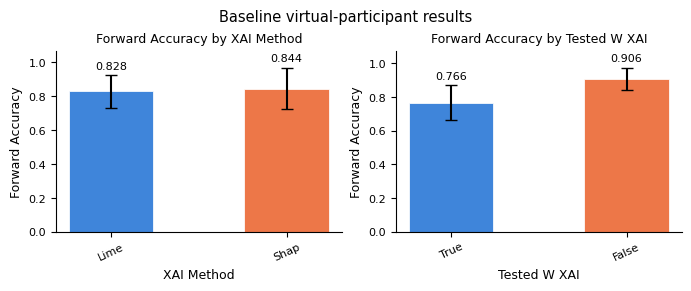

In [19]:
# Delete this cell after passing all tests. This is NOT for interviewees

analysis = xaikitTest.analyze_iv_dv(iv="xai_method", dv="forward_accuracy")
print("--- xai_method x forward_accuracy ---")
display(analysis.descriptives)

xaikitTest.plot_results_grid(
    ivs=list(iv_config.keys()),
    dvs=list(dvs.keys()),
    phase="testing",
    title="Baseline virtual-participant results",
)

<details>
<summary>Click here to see the correct code</summary>

```python
analysis = xaikitTest.analyze_iv_dv(iv="xai_method", dv="forward_accuracy")
print("--- xai_method x forward_accuracy ---")
display(analysis.descriptives)

xaikitTest.plot_results_grid(
    ivs=list(iv_config.keys()),
    dvs=list(dvs.keys()),
    phase="testing",
    title="Baseline virtual-participant results",
)
```

</details>

### Step 4.2 Two-IV interaction plot

**Goal:**

Plot explanation presence against explanation method as a grouped bar chart, to
see whether the two factors interact.

**Instruction:**

Put `tested_w_xai` on the x axis and `xai_method` in the hue, plot
`forward_accuracy` for the testing phase, and give both factors readable
display labels rather than raw level names.

<details>
<summary>Hint</summary>

Call `xaikitTest.plot_dv_by_two_ivs(...)` with `x_iv`, `hue_iv`, `dv`, `phase`, `x_levels`, `hue_levels`, `x_labels`, `hue_labels` and `title`.

</details>

In [20]:
# YOUR CODE HERE

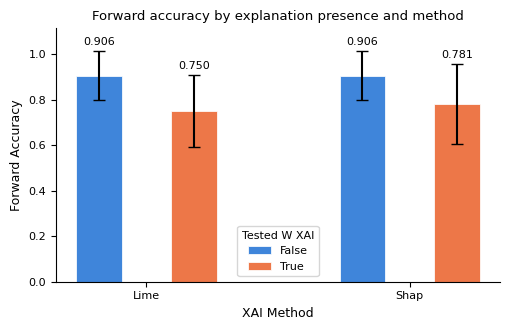

In [21]:
# Delete this cell after passing all tests. This is NOT for interviewees

accuracy_plot = xaikitTest.plot_dv_by_two_ivs(
    x_iv="xai_method",
    hue_iv="tested_w_xai",
    dv="forward_accuracy",
    phase="testing",
    x_levels=[True, False],
    hue_levels=["lime", "shap"],
    x_labels={True: "With explanation", False: "Without explanation"},
    hue_labels={"lime": "LIME", "shap": "SHAP"},
    title="Forward accuracy by explanation presence and method",
)
accuracy_plot.figure;

<details>
<summary>Click here to see the correct code</summary>

```python
accuracy_plot = xaikitTest.plot_dv_by_two_ivs(
    x_iv="tested_w_xai",
    hue_iv="xai_method",
    dv="forward_accuracy",
    phase="testing",
    x_levels=[True, False],
    hue_levels=["lime", "shap"],
    x_labels={True: "With explanation", False: "Without explanation"},
    hue_labels={"lime": "LIME", "shap": "SHAP"},
    title="Forward accuracy by explanation presence and method",
)
accuracy_plot.figure;
```

</details>

### Step 4.3 Test pairwise condition differences

**Goal:**

Compare every crossed condition cell against every other, with a family-wise
error correction, so a difference you can see in the plot can be reported.

**Instruction:**

Run pairwise comparisons of `forward_accuracy` across `xai_method` x
`tested_w_xai` on the testing rows, pairing within participant and correcting
with Holm. Display the table rounded to 4 decimals.

<details>
<summary>Hint</summary>

*   `from src.statistical_analyst import pairwise_condition_tests`
*   Pass `value_col`, `condition_cols`, `participant_col="participantId"` and
    `correction="holm"`.
*   The result's `.table` is the frame to display.

</details>

In [22]:
# YOUR CODE HERE

In [23]:
# Delete this cell after passing all tests. This is NOT for interviewees

from src.statistical_analyst import pairwise_condition_tests

pairwise_results = pairwise_condition_tests(
    testing_results,
    value_col="forward_accuracy",
    condition_cols=["xai_method", "tested_w_xai"],
    participant_col="participantId",
    correction="holm",
)
display(pairwise_results.table.round(4))

,condition_a,condition_b,test,n_a,n_b,mean_a,mean_b,mean_difference,statistic,p_value,p_value_corrected,reject_null
0,xai_method=lime | tested_w_xai=False,xai_method=lime | tested_w_xai=True,paired_t,8,8,0.9062,0.7500,0.1562,1.9296,0.0950,0.4749,False
1,xai_method=lime | tested_w_xai=False,xai_method=shap | tested_w_xai=False,welch_t,8,8,0.9062,0.9062,0.0000,0.0000,1.0000,1.0000,False
2,xai_method=lime | tested_w_xai=False,xai_method=shap | tested_w_xai=True,welch_t,8,8,0.9062,0.7812,0.1250,1.4402,0.1761,0.5282,False
3,xai_method=lime | tested_w_xai=True,xai_method=shap | tested_w_xai=False,welch_t,8,8,0.7500,0.9062,-0.1562,-1.9296,0.0769,0.4613,False
4,xai_method=lime | tested_w_xai=True,xai_method=shap | tested_w_xai=True,welch_t,8,8,0.7500,0.7812,-0.0312,-0.3140,0.7582,1.0000,False
5,xai_method=shap | tested_w_xai=False,xai_method=shap | tested_w_xai=True,paired_t,8,8,0.9062,0.7812,0.1250,1.8708,0.1036,0.4749,False


<details>
<summary>Click here to see the correct code</summary>

```python
from src.statistical_analyst import pairwise_condition_tests

pairwise_results = pairwise_condition_tests(
    testing_results,
    value_col="forward_accuracy",
    condition_cols=["xai_method", "tested_w_xai"],
    participant_col="participantId",
    correction="holm",
)
display(pairwise_results.table.round(4))
```

</details>

### Step 4.4 Compare against the published human data

**Goal:**

See how the fitted CoAX model that this study's baseline stands in for
compares to the real participants it was validated against -- with the
same plot and fit-stats table the running server serves at
`GET /api/human-comparison/coax`, not a separately built report.

**Instruction:**

Call `server.pipeline.human_comparison_payload("coax")` -- the exact
function `server/app.py` calls behind that endpoint. It reads files
already precomputed under `assets/` (`build_human_vs_model_plot_data.py`,
`build_human_vs_model_plots.py`, `build_human_vs_model_fit_stats.py`) and
returns the PNG, the panel data and the NLL/BIC fit-stats table together.
Display the PNG and turn `fit_stats` into a flat table.

<details>
<summary>Hint</summary>

```python
payload = pipeline.human_comparison_payload("coax")
```

*   `payload["plot_png"]` is a `data:image/png;base64,...` URI -- decode
    the part after the comma and pass the bytes to `IPython.display.Image`.
*   `payload["fit_stats"]["tables"][0]` has `models`, each with a `cells`
    dict keyed by facet (`None XAI`, `Importance XAI`, `Attribution XAI`)
    -- flatten it into a `pd.DataFrame` with one row per `(model, facet)`.
*   CoAX's fit-stats table is transcribed from the published paper, so it
    also carries DT/KNN/MLP baselines alongside CoAX itself.

</details>

In [24]:
# YOUR CODE HERE

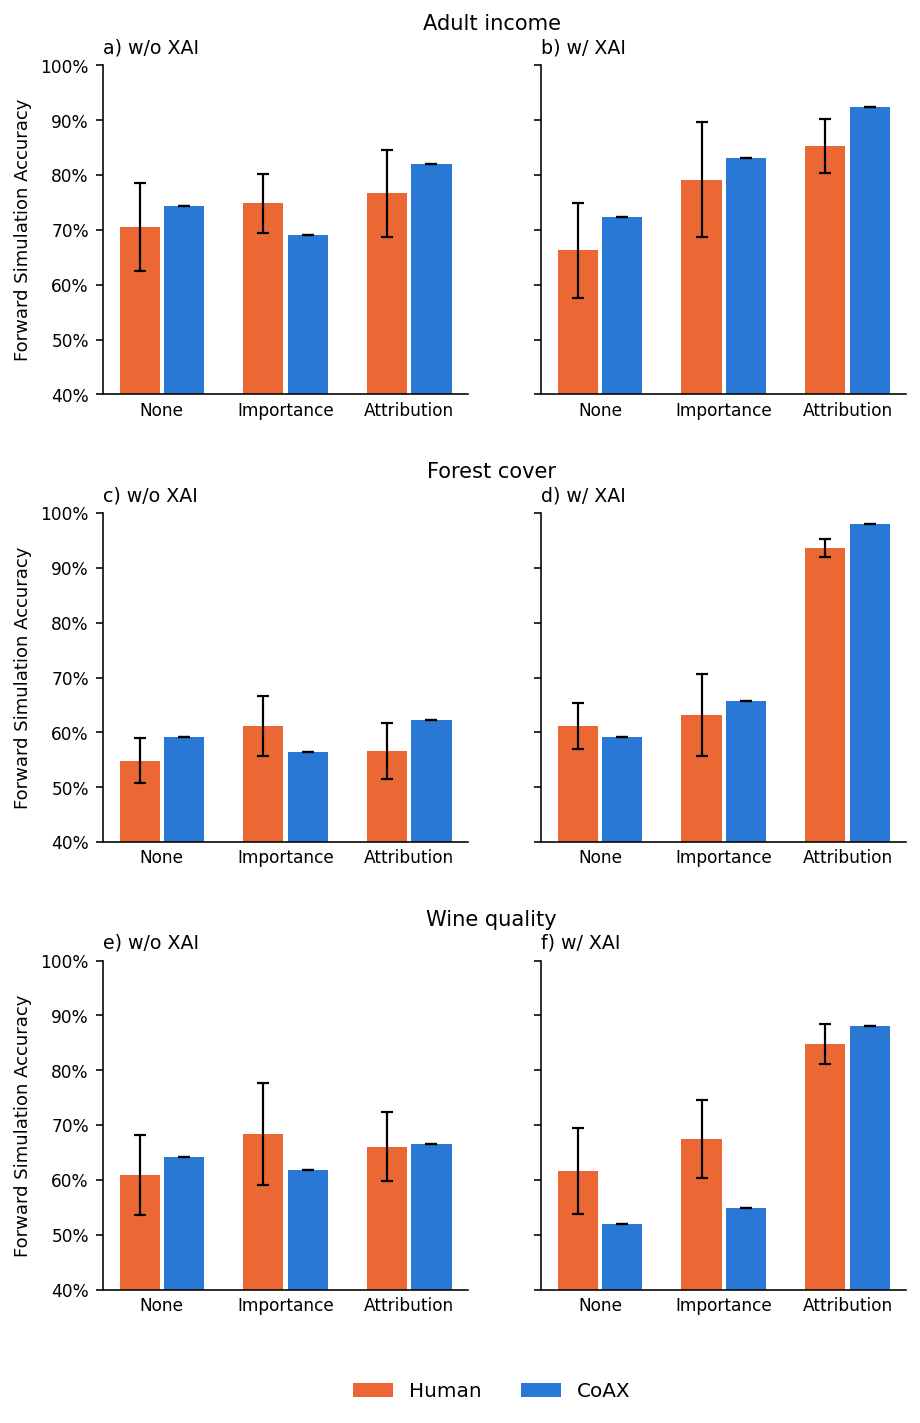

,model,facet,nll_mean,nll_sd,bic_mean,bic_sd,n
0,DT,None XAI,0.61,0.10,27.7,3.6,None
1,DT,Importance XAI,0.60,0.10,27.4,3.6,None
2,DT,Attribution XAI,0.58,0.09,26.7,3.2,None
3,KNN,None XAI,0.58,0.14,26.7,5.0,None
4,KNN,Importance XAI,0.59,0.11,27.0,4.0,None
5,KNN,Attribution XAI,0.46,0.16,22.3,5.8,None
6,MLP,None XAI,0.61,0.07,27.7,2.5,None
7,MLP,Importance XAI,0.60,0.09,27.4,3.2,None
8,MLP,Attribution XAI,0.43,0.11,21.3,4.0,None
9,CoAX,None XAI,0.47,0.22,26.0,7.9,None


In [25]:
# Delete this cell after passing all tests. This is NOT for interviewees

payload = pipeline.human_comparison_payload("coax")
if payload is None:
    raise FileNotFoundError(
        "No precomputed human comparison for coax. Run "
        "assets/build_human_vs_model_plot_data.py, assets/build_human_vs_model_plots.py "
        "and assets/build_human_vs_model_fit_stats.py first."
    )

_, encoded = payload["plot_png"].split(",", 1)
display(Image(data=base64.b64decode(encoded)))

fit_stats_rows = [
    {"model": model["label"], "facet": facet, **cell}
    for table in payload["fit_stats"]["tables"]
    for model in table["models"]
    for facet, cell in model["cells"].items()
]
fit_stats_table = pd.DataFrame(fit_stats_rows)
display(fit_stats_table.round(3))

<details>
<summary>Click here to see the correct code</summary>

```python
payload = pipeline.human_comparison_payload("coax")
if payload is None:
    raise FileNotFoundError(
        "No precomputed human comparison for coax. Run "
        "assets/build_human_vs_model_plot_data.py, assets/build_human_vs_model_plots.py "
        "and assets/build_human_vs_model_fit_stats.py first."
    )

_, encoded = payload["plot_png"].split(",", 1)
display(Image(data=base64.b64decode(encoded)))

fit_stats_rows = [
    {"model": model["label"], "facet": facet, **cell}
    for table in payload["fit_stats"]["tables"]
    for model in table["models"]
    for facet, cell in model["cells"].items()
]
fit_stats_table = pd.DataFrame(fit_stats_rows)
display(fit_stats_table.round(3))
```

</details>

## Where to go next

*   **`coxam_workflow_tutorial.ipynb`** replaces the baseline cognitive model
    with **CoXAM**, a fitted model of how people read rule- and weight-based
    explanations.
*   **`sim2real_workflow_tutorial.ipynb`** replaces it with **Sim2Real**, a
    fitted model of counterfactual reasoning over explanation *properties*.

Both keep the four phases you just ran.